<center><h1>Yahoo Music</h1></center>

In [1]:
from src import *
import src
import numpy as np
from importlib import reload
import pandas as pd
reload(src)
import matplotlib.pyplot as plt
from math import sqrt

import warnings
warnings.filterwarnings('ignore')

In [2]:
def df_to_latex(df, legenda):
    latex = r'''\begin{table}[]
                \centering
                        '''
    latex = latex + df.to_latex(index=False, header=True, 
                                column_format='c'*len(df.columns.to_list()))
    latex = latex + r'''
                    \caption{%s}
                    \end{table}
                        ''' % legenda 
    return latex

## Pré-processamento

#### Carregamento

In [3]:
df = pd.read_csv('data/raw/yahoo_music/dataset/ydata-ymusic-user-artist-ratings-v1_0.txt', sep='\t', names=['userId', 'artistId', 'rating'])

In [4]:
df

,userId,artistId,rating
0,1,1000125,90
1,1,1006373,100
2,1,1006978,90
3,1,1007035,100
4,1,1007098,100
...,...,...,...
115579435,1948882,1043454,90
115579436,1948882,1097508,90
115579437,1948882,1098099,90
115579438,1948882,1098953,90


#### Cortando notas abaixo de 100

In [5]:
df = df[df['rating'] >= 200]
df.shape[0]

330865

#### Metadados de itens

In [6]:
itens = pd.read_csv('data/raw/yahoo_music/dataset/ydata-ymusic-artist-names-v1_0.txt', 
                sep='\t', 
                names=['artistId', 'artistName'], 
               encoding='ISO-8859-1')

In [7]:
itens.shape[0]

97956

In [8]:
itens['artistId'].nunique()

97956

#### Gêneros obtidos com o DiscoGS

In [26]:
import json

with open('data/processed/yahoo_music/yahoo_music_genres.json', 'r', encoding='utf-8') as file:
    dic = json.load(file)

In [27]:
dic_tratado = {"artistId": dic.keys(), "genres": [value[1] for value in dic.values()]}

In [28]:
g = pd.DataFrame(dic_tratado)

In [29]:
g['artistId'] = g['artistId'].astype(int)

In [13]:
g

,artistId,genres
0,1000001,"[Hip Hop, Funk / Soul]"
1,1000002,"[Hip Hop, Rock]"
2,1000003,[Rock]
3,1000004,"[Rock, Pop]"
4,1000005,"[Jazz, Rock]"
...,...,...
97949,1101110,[Funk / Soul]
97950,1101111,[Hip Hop]
97951,1101112,[Rock]
97952,1101113,[Electronic]


Número de gêneros presentes

In [14]:
g.explode('genres')['genres'].nunique()

15

In [15]:
g.explode('genres')['genres'].unique()

array(['Hip Hop', 'Funk / Soul', 'Rock', 'Pop', 'Jazz', 'Electronic', nan,
       'Latin', 'Folk, World, & Country', 'Stage & Screen', 'Classical',
       'Reggae', 'Non-Music', 'Brass & Military', 'Blues', "Children's"],
      dtype=object)

Pegando ID de artistas sem gêneros para tirar da base de ratings

In [30]:
artistas_sem_generos = g[g['genres'].str.len() == 0]['artistId'].to_list()

In [31]:
len(artistas_sem_generos)

6654

Tirando artistas sem gêneros

In [18]:
g = g[g['genres'].str.len() != 0]

In [19]:
g.shape[0]

91300

In [20]:
print(df_to_latex(g.head(), 'Primeiras 5 linhas do conjunto de metadados de artistas presentes no conjunto de dados Yahoo! Music com os gêneros obtidos pela API Discogs'))

\begin{table}[]
                \centering
                        \begin{tabular}{cc}
\toprule
artistId & genres \\
\midrule
1000001 & ['Hip Hop', 'Funk / Soul'] \\
1000002 & ['Hip Hop', 'Rock'] \\
1000003 & ['Rock'] \\
1000004 & ['Rock', 'Pop'] \\
1000005 & ['Jazz', 'Rock'] \\
\bottomrule
\end{tabular}

                    \caption{Primeiras 5 linhas do conjunto de metadados de artistas presentes no conjunto de dados Yahoo! Music com os gêneros obtidos pela API Discogs}
                    \end{table}
                        


Deixando igual ao MovieLens

In [21]:
g['genres'] = g['genres'].str.join('|')

In [22]:
g.head()

,artistId,genres
0,1000001,Hip Hop|Funk / Soul
1,1000002,Hip Hop|Rock
2,1000003,Rock
3,1000004,Rock|Pop
4,1000005,Jazz|Rock


#### Cruzando IDs de filmes com os gêneros

In [23]:
artistas_com_generos = pd.merge(itens, g, on='artistId', how='inner')

In [ ]:
artistas_com_generos.to_csv('data/processed/yahoo_music/yahoo_music_artists_metadata_with_genres.csv', index=False, header=False)

#### Tirando artistas cujo gêneros não foram encontrados

In [24]:
artistas_sem_generos = g[g['genres'].str.len() == 0]['artistId'].to_list()

In [ ]:
artistas_com_generos = pd.read_csv('data/processed/yahoo_music/yahoo_music_artists_metadata_with_genres.csv', 
                                   names=['artistId', 'artistName', 'genre'])

In [ ]:
artistas_com_generos

In [32]:
df = df[~df['artistId'].isin(artistas_sem_generos)]

In [33]:
df

,userId,artistId,rating
1384,25,1007340,255
1405,25,1024052,255
1408,25,1029091,255
1409,25,1030393,255
7317,91,1019658,255
...,...,...,...
115559634,1948570,1053387,255
115565373,1948674,1045704,255
115575698,1948815,1020036,255
115575705,1948815,1030710,255


#### Cortando linhas por frequência de avaliações de usuários

In [34]:
f = df['userId'].value_counts()
f_mantain = f[f >= 100].index.to_list()

In [35]:
df[df['userId'].isin(f_mantain)].shape[0]

112523

In [36]:
df = df[df['userId'].isin(f_mantain)]
df.shape[0]

112523

In [ ]:
df.columns

In [37]:
df.to_csv('data/processed/yahoo_music/yahoo_music_tratado.csv', index=False, header=None)

In [38]:
userColumn='userId'
itemColumn='artistId'
ratingColumn='rating'

In [39]:
loader = DataLoader(file_path='data/processed/yahoo_music/yahoo_music_tratado.csv',
                    separator=',',
                    header=['userId', 'artistId', 'rating'],
                    genre_data_path='data/processed/yahoo_music/yahoo_music_artists_metadata_with_genres.csv',
                    genre_data_separator=',',
                    genre_data_header=['artistId', 'artistName', 'genres'],
                    genre_item_column='artistId',
                    genre_genre_column='genres',
                    genre_genre_separator='|',
                    genre_data_encoding='ISO-8859-1'
                    )

24/09/08 19:23:45 WARN Utils: Your hostname, david-Nitro resolves to a loopback address: 127.0.1.1; using 192.168.15.14 instead (on interface wlp9s0)
24/09/08 19:23:45 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/09/08 19:23:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
24/09/08 19:23:46 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
24/09/08 19:23:46 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [40]:
df = loader.load_data()
df_pandas = loader.convert_to_pandas(df)
genres_map = loader.get_genre_map()
# (train, test) = loader.train_test_separator(df)

In [ ]:
df_pandas

## ALS

In [41]:
kfold = KFOLD(df_pandas, 'FC', userColumn, itemColumn, ratingColumn, genres_map)

24/09/08 19:23:51 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [42]:
results = kfold.run_cross_validation()

1) Running FC
******************************
Lambda = 0.0
Reseting metrics lists
********************
FAIRNESS MEASURE: kullback-leibler
=====1º Fold=====
Train/test spliting
Instantiating ALS...


24/09/08 19:23:57 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
24/09/08 19:24:00 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
24/09/08 19:24:01 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


Getting n = 100 predictions for each user


Calibrating...
CALCULATING MRMC
MRMC = 0.3791073237901159
CALCULATING MACE
MACE = 0.06705780069010832
CALCULATING MAP
MAP = 0.024789734075448364
CALCULATING MRR
MRR = 0.02538548752834467
=====2º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.3298222912716863
CALCULATING MACE
MACE = 0.0626631309182721
CALCULATING MAP
MAP = 0.011092558235415379
CALCULATING MRR
MRR = 0.011092558235415379
=====3º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.36188538956723904
CALCULATING MACE
MACE = 0.06380782903596617
CALCULATING MAP
MAP = 0.020983302411873843
CALCULATING MRR
MRR = 0.021153370439084725
=====4º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.3647647644461712
CALCULATING MACE
MACE = 0.06290833697401464
CALCULATING MAP
MAP = 0.02154710

In [43]:
results

,Lambda,FairnessMeasure,Statistic,MACE,MRMC,MAP,MRR
0,0.0,kullback-leibler,mean,0.064213,0.358250,0.018370,0.018578
1,0.0,kullback-leibler,stdev,0.000792,0.008079,0.002602,0.002643
0,0.0,hellinger,mean,0.064213,0.718970,0.018370,0.018578
1,0.0,hellinger,stdev,0.000792,0.008705,0.002602,0.002643
0,0.0,pearson,mean,0.064213,0.360628,0.018370,0.018578
...,...,...,...,...,...,...,...
1,1.0,kullback-leibler,stdev,0.000210,0.000677,0.005474,0.005871
0,1.0,hellinger,mean,0.030136,0.398809,0.025886,0.026335
1,1.0,hellinger,stdev,0.000197,0.001165,0.005370,0.005677
0,1.0,pearson,mean,0.043988,0.071983,0.021281,0.021774


In [44]:
results.to_csv('results/yahoo_music/results_yahoo_music2.csv', index=False)

In [ ]:
results = pd.read_csv('results/yahoo_music/results_yahoo_music.csv')

In [ ]:
#results.to_csv('results/yahoo_movies/results_yahoo_movies.csv', index=False)

In [ ]:
tradeoff_weights = results['Lambda'].drop_duplicates().to_list()
mrmc_kl = results[(results['FairnessMeasure'] == 'kullback-leibler') & (results['Statistic'] == 'mean')]['MAP'].to_list()
mrmc_he = results[(results['FairnessMeasure'] == 'hellinger') & (results['Statistic'] == 'mean')]['MAP'].to_list()
mrmc_pe = results[(results['FairnessMeasure'] == 'pearson') & (results['Statistic'] == 'mean')]['MAP'].to_list()

# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(tradeoff_weights, mrmc_kl, marker='o', linestyle='-', color='b', label='Kullback-Leibler')
plt.plot(tradeoff_weights, mrmc_he, marker='s', linestyle='-', color='r', label='Hellinger')
plt.plot(tradeoff_weights, mrmc_pe, marker='^', linestyle='-', color='g', label='Pearson chi-quadrado')

plt.xlabel('λ')
plt.xticks(np.arange(0.0, 1.1, 0.1))
plt.ylabel('Mean rank miscalibration (MRMC)')
plt.title('MovieLens com ALS')
plt.legend()
plt.grid(True)
plt.show()


#### CRIANDO GRÁFICOS

In [49]:
def show_graphic(dataset_name, metric, title):
    short_metric = metric[metric.find('(')+1: metric.find(')')]
    tradeoff_weights = results['Lambda'].drop_duplicates().to_list()
    mrmc_kl = results[(results['FairnessMeasure'] == 'kullback-leibler') & (results['Statistic'] == 'mean')][short_metric].to_list()
    mrmc_he = results[(results['FairnessMeasure'] == 'hellinger') & (results['Statistic'] == 'mean')][short_metric].to_list()
    mrmc_pe = results[(results['FairnessMeasure'] == 'pearson') & (results['Statistic'] == 'mean')][short_metric].to_list()

    mrmc_he_err = results[(results['FairnessMeasure'] == 'hellinger') & (results['Statistic'] == 'stdev')][short_metric].to_list()
    mrmc_he_err = [std/sqrt(5) for std in mrmc_he_err]
    mrmc_kl_err = results[(results['FairnessMeasure'] == 'kullback-leibler') & (results['Statistic'] == 'stdev')][short_metric].to_list()
    mrmc_kl_err = [std/sqrt(5) for std in mrmc_kl_err]
    mrmc_pe_err = results[(results['FairnessMeasure'] == 'pearson') & (results['Statistic'] == 'stdev')][short_metric].to_list()
    mrmc_pe_err = [std/sqrt(5) for std in mrmc_pe_err]
    
    # Plotando o gráfico com barras de erro
    plt.figure(figsize=(10, 6))
    plt.errorbar(tradeoff_weights, mrmc_kl, yerr=mrmc_kl_err, marker='o', linestyle='-', color='b', label='Kullback-Leibler', capsize=5) 
    plt.errorbar(tradeoff_weights, mrmc_he, yerr=mrmc_he_err, marker='s', linestyle='-', color='r', label='Hellinger', capsize=5) 
    plt.errorbar(tradeoff_weights, mrmc_pe, yerr=mrmc_pe_err, marker='^', linestyle='-', color='g', label='Pearson chi-quadrado', capsize=5)
    
    # Configurando os rótulos e título
    plt.xlabel(r'$\lambda$')
    plt.ylabel(metric)
    plt.title(title)
    
    # Definindo os valores do eixo x para incrementar de 0.1 em 0.1
    plt.xticks(np.arange(0.0, 1.1, 0.1))
    
    plt.legend()
    plt.grid(True)
    #plt.savefig(f'results/{dataset_name}/graphs/{dataset_name}_{metric}.pgf'.replace(' ', '_'))
    plt.savefig(f'results/{dataset_name}/graphs/{dataset_name}_{metric}.pdf'.replace(' ', '_'), bbox_inches='tight')
    plt.show()
    

==========Mean Average Calibration Error (MACE)==========


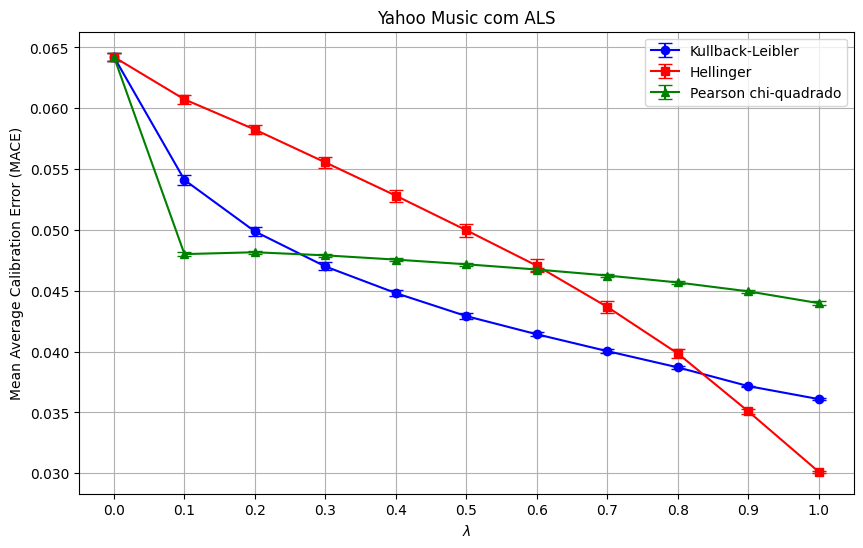

==========Mean Rank Miscalibration (MRMC)==========


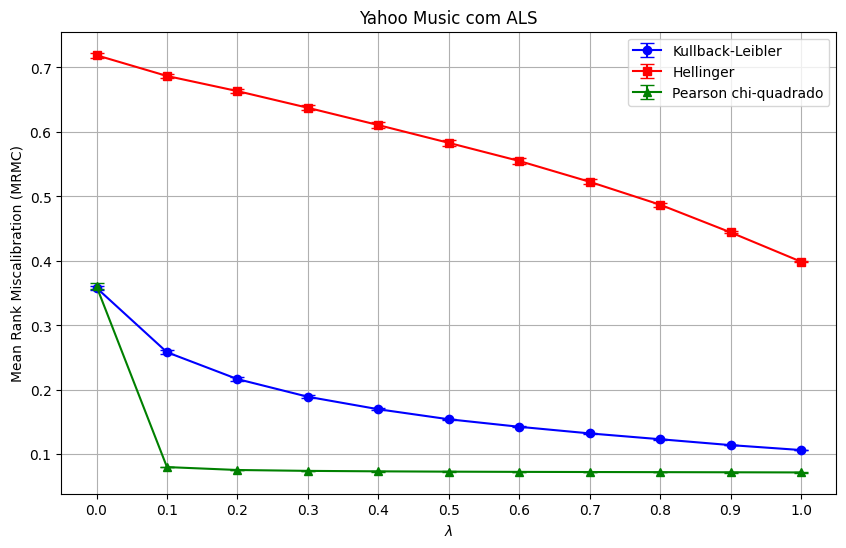

==========Mean Average Precision (MAP)==========


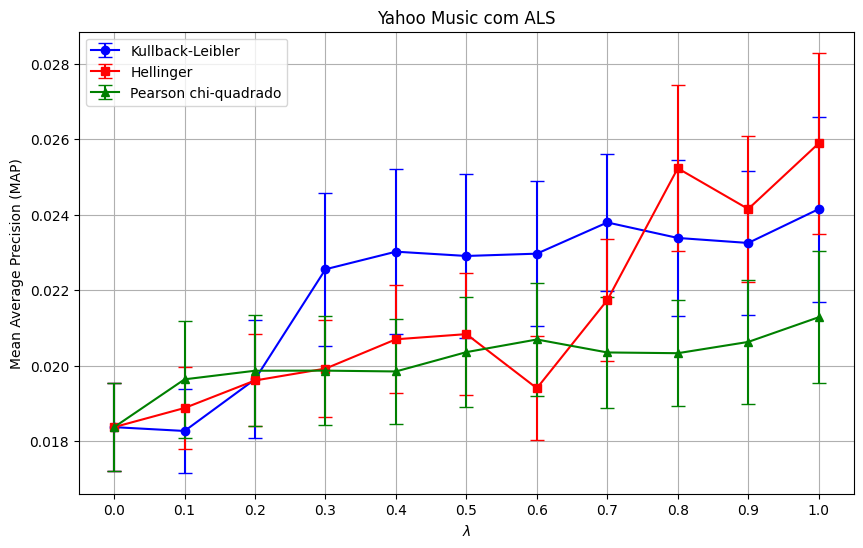

==========Mean Reciprocal Rank (MRR)==========


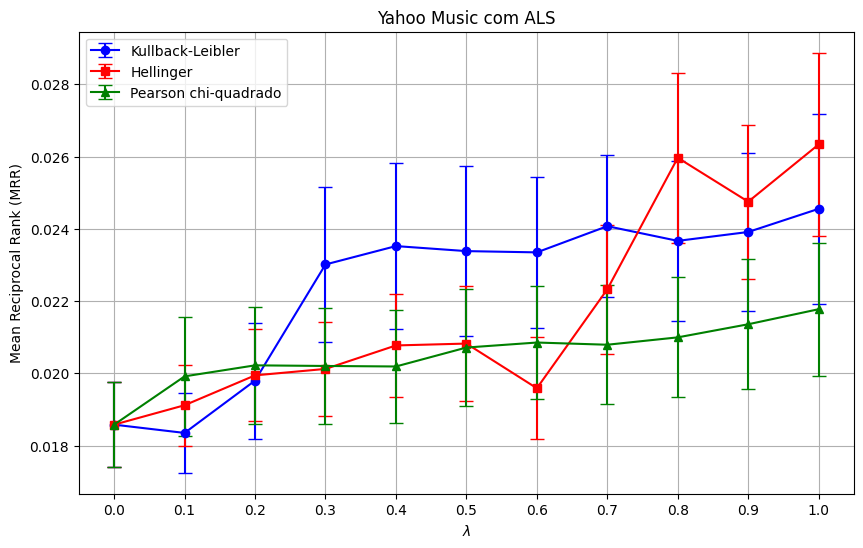

In [50]:
for metric in ['Mean Average Calibration Error (MACE)', 'Mean Rank Miscalibration (MRMC)', 'Mean Average Precision (MAP)', 'Mean Reciprocal Rank (MRR)']:
    print('=' * 10 + metric + '=' * 10)
    show_graphic('yahoo_music', metric, 'Yahoo Music com ALS')



In [ ]:
predictions_user_map

In [ ]:
distributions = Distributions(train.toPandas(), userColumn, itemColumn, genres_map)

In [ ]:
distributions.show_userProfileDist_userRecDist(predictions_user_map, 305)


# FBC-kNN

In [ ]:
df_genres = loader.genre_data

In [ ]:
df_genres

In [ ]:
df_expanded = df_genres['genres'].str.get_dummies(sep='|')

In [ ]:
df_final = pd.concat([df_genres[['item']], df_expanded], axis=1)

In [ ]:
df_final.index = df_final['item']

In [ ]:
df_mv_genres = df_final.drop(columns = ['item'])

In [ ]:
df_mv_genres

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
cosine_sim = cosine_similarity(df_mv_genres)

In [ ]:
df_cosine_sim = pd.DataFrame(cosine_sim, index = df_mv_genres.index, columns = df_mv_genres.index)

In [ ]:
df_cosine_sim

In [ ]:
similar_itens = list(df_cosine_sim.loc[1].sort_values(ascending=False).keys())[:102]
similar_itens.remove(1)
#rated_by_u = set(df_pandas[(df_pandas[userColumn] == 1) & (df_pandas[ratingColumn] > 0)][itemColumn].to_list())
#intersect = list(similar_itens.intersection(rated_by_u))[:101]


In [ ]:
def get_recommendatinon(movieId, userId, df_sim, df_ratings, k):
    similar_itens = list(df_sim.loc[movieId].sort_values(ascending=False).keys())[:k+2]
    similar_itens.remove(movieId)
    return similar_itens()


In [ ]:
#def get_recommendatinon(movieId, userId, df_sim, df_ratings, k):
#    similar_itens = set(df_sim.loc[movieId].sort_values(ascending=False).keys())
#    rated_by_u = set(df_ratings[(df_ratings[userColumn] == userId) & (df_ratings[ratingColumn] > 0)][itemColumn].to_list())
#    intersect = list(similar_itens.intersect(rated_by_u))[:k+1]
